# Stage 2: Data Collection & Data Understanding
## Heart Disease Prediction Using Patient Health Data

**Dataset:** Cleveland Heart Disease Dataset — UCI Machine Learning Repository  
**File:** `heart-disease.csv` | **Shape:** 303 rows × 14 columns

---

## 2.1 Dataset Source & Collection Context

The **Cleveland Heart Disease Dataset** was originally collected at the **Cleveland Clinic Foundation** by Robert Detrano, M.D., Ph.D. It was donated to the UCI Machine Learning Repository in 1988 and has since become one of the most widely used benchmark datasets in medical machine learning research.

**Dataset URL:** https://archive.ics.uci.edu/ml/datasets/Heart+Disease

### Data Collection Methodology (Original Study):
- **Patient Population:** Adult patients referred for coronary angiography at Cleveland Clinic
- **Ground Truth:** Presence of heart disease confirmed by angiographic results (stenosis > 50% diameter narrowing = positive)
- **Original Target:** Multi-class (0–4 severity), but the standard benchmark uses **binary** (0 = no disease, 1 = disease)
- **Total Attributes:** 76 original clinical measurements (we use the standard 14-attribute subset)

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
PALETTE = ['#e74c3c', '#2ecc71']   # Red = No Disease, Green = Heart Disease

print("Libraries loaded successfully.")
print(f"Pandas version: {pd.__version__} | NumPy version: {np.__version__}")

Libraries loaded successfully.
Pandas version: 3.0.2 | NumPy version: 2.4.4


## 2.2 Load the Dataset

In [5]:
# Load dataset
df = pd.read_csv(r"C:\Users\Anagha\Downloads\Heart-disease-prediction\Heart-disease-prediction\heart-disease.csv")

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} patients × {df.shape[1]} attributes")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")
print("\nFirst 5 rows:")
df.head()

Dataset loaded successfully!
Shape: 303 patients × 14 attributes
Memory usage: 33.27 KB

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 2.3 Feature Dictionary

Below is a complete data dictionary for all 13 clinical features:

In [6]:
feature_dict = {
    'Feature': ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
                'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
    'Full Name': [
        'Age', 'Sex', 'Chest Pain Type', 'Resting Blood Pressure',
        'Serum Cholesterol', 'Fasting Blood Sugar', 'Resting ECG Results',
        'Max Heart Rate Achieved', 'Exercise-Induced Angina', 'ST Depression (Oldpeak)',
        'Slope of Peak Exercise ST', 'Major Vessels (Fluoroscopy)', 'Thalassemia Type', 'Target'
    ],
    'Type': [
        'Numerical', 'Categorical', 'Categorical', 'Numerical', 'Numerical',
        'Categorical', 'Categorical', 'Numerical', 'Categorical', 'Numerical',
        'Categorical', 'Numerical', 'Categorical', 'Categorical'
    ],
    'Values / Range': [
        '29–77 years', '0 = Female, 1 = Male',
        '0=Typical Angina, 1=Atypical Angina, 2=Non-Anginal, 3=Asymptomatic',
        '94–200 mm Hg', '126–564 mg/dl',
        '0 = FBS ≤ 120 mg/dl, 1 = FBS > 120 mg/dl',
        '0=Normal, 1=ST-T Abnormality, 2=LV Hypertrophy',
        '71–202 bpm', '0 = No, 1 = Yes',
        '0.0–6.2', '0=Upsloping, 1=Flat, 2=Downsloping',
        '0–4 vessels', '0=Normal, 1=Fixed Defect, 2=Reversible Defect, 3=Unknown',
        '0 = No Disease, 1 = Heart Disease'
    ]
}

dict_df = pd.DataFrame(feature_dict)
print("=" * 80)
print("FEATURE DICTIONARY — CLEVELAND HEART DISEASE DATASET")
print("=" * 80)
print(dict_df.to_string(index=False))

FEATURE DICTIONARY — CLEVELAND HEART DISEASE DATASET
 Feature                   Full Name        Type                                                     Values / Range
     age                         Age   Numerical                                                        29–77 years
     sex                         Sex Categorical                                               0 = Female, 1 = Male
      cp             Chest Pain Type Categorical 0=Typical Angina, 1=Atypical Angina, 2=Non-Anginal, 3=Asymptomatic
trestbps      Resting Blood Pressure   Numerical                                                       94–200 mm Hg
    chol           Serum Cholesterol   Numerical                                                      126–564 mg/dl
     fbs         Fasting Blood Sugar Categorical                           0 = FBS ≤ 120 mg/dl, 1 = FBS > 120 mg/dl
 restecg         Resting ECG Results Categorical                     0=Normal, 1=ST-T Abnormality, 2=LV Hypertrophy
 thalach     Max He

## 2.4 Basic Dataset Inspection

In [7]:
# Data types and non-null counts
print("=" * 50)
print("DATA TYPES & NON-NULL COUNTS")
print("=" * 50)
print(df.info())

DATA TYPES & NON-NULL COUNTS
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None


In [8]:
# Check for missing values
missing = df.isnull().sum()
print("=" * 40)
print("MISSING VALUES PER COLUMN")
print("=" * 40)
print(missing)
print(f"\nTotal missing values: {missing.sum()}")
if missing.sum() == 0:
    print("✅ No missing values detected — dataset is clean.")
else:
    print("⚠️  Missing values found — will handle in Stage 3.")

MISSING VALUES PER COLUMN
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing values: 0
✅ No missing values detected — dataset is clean.


In [9]:
# Duplicate rows check
dups = df.duplicated().sum()
print(f"Duplicate rows: {dups}")
if dups == 0:
    print("✅ No duplicate rows found.")
else:
    print(f"⚠️  {dups} duplicates detected — will drop in Stage 3.")

Duplicate rows: 1
⚠️  1 duplicates detected — will drop in Stage 3.


## 2.5 Statistical Summary

In [10]:
print("DESCRIPTIVE STATISTICS — NUMERICAL FEATURES")
print("=" * 70)
print(df.describe().round(2).T.to_string())

DESCRIPTIVE STATISTICS — NUMERICAL FEATURES
          count    mean    std    min    25%    50%    75%    max
age       303.0   54.37   9.08   29.0   47.5   55.0   61.0   77.0
sex       303.0    0.68   0.47    0.0    0.0    1.0    1.0    1.0
cp        303.0    0.97   1.03    0.0    0.0    1.0    2.0    3.0
trestbps  303.0  131.62  17.54   94.0  120.0  130.0  140.0  200.0
chol      303.0  246.26  51.83  126.0  211.0  240.0  274.5  564.0
fbs       303.0    0.15   0.36    0.0    0.0    0.0    0.0    1.0
restecg   303.0    0.53   0.53    0.0    0.0    1.0    1.0    2.0
thalach   303.0  149.65  22.91   71.0  133.5  153.0  166.0  202.0
exang     303.0    0.33   0.47    0.0    0.0    0.0    1.0    1.0
oldpeak   303.0    1.04   1.16    0.0    0.0    0.8    1.6    6.2
slope     303.0    1.40   0.62    0.0    1.0    1.0    2.0    2.0
ca        303.0    0.73   1.02    0.0    0.0    0.0    1.0    4.0
thal      303.0    2.31   0.61    0.0    2.0    2.0    3.0    3.0
target    303.0    0.54   0.50  

In [11]:
# Deeper statistical view — skewness and kurtosis
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

stats_df = pd.DataFrame({
    'Mean':     df[numerical_cols].mean().round(2),
    'Median':   df[numerical_cols].median().round(2),
    'Std Dev':  df[numerical_cols].std().round(2),
    'Min':      df[numerical_cols].min(),
    'Max':      df[numerical_cols].max(),
    'Skewness': df[numerical_cols].skew().round(3),
    'Kurtosis': df[numerical_cols].kurtosis().round(3)
})

print("EXTENDED STATISTICAL SUMMARY (Numerical Features Only)")
print("=" * 70)
print(stats_df.to_string())
print("\nNote: Skewness > 1 or < -1 indicates a highly skewed distribution.")
print("      'oldpeak' is expected to be right-skewed (most patients have low ST depression).")

EXTENDED STATISTICAL SUMMARY (Numerical Features Only)
            Mean  Median  Std Dev    Min    Max  Skewness  Kurtosis
age        54.37    55.0     9.08   29.0   77.0    -0.202    -0.542
trestbps  131.62   130.0    17.54   94.0  200.0     0.714     0.929
chol      246.26   240.0    51.83  126.0  564.0     1.143     4.505
thalach   149.65   153.0    22.91   71.0  202.0    -0.537    -0.062
oldpeak     1.04     0.8     1.16    0.0    6.2     1.270     1.576

Note: Skewness > 1 or < -1 indicates a highly skewed distribution.
      'oldpeak' is expected to be right-skewed (most patients have low ST depression).


## 2.6 Target Variable Analysis

TARGET CLASS DISTRIBUTION
No Heart Disease (0): 138 patients  (45.5%)
Heart Disease    (1): 165 patients  (54.5%)

Class Imbalance Ratio: 1.20:1 (Disease:No Disease)

Observation: Slight positive skew — 54.5% of patients have heart disease.
The imbalance is mild and will be accounted for using stratified train/test split.


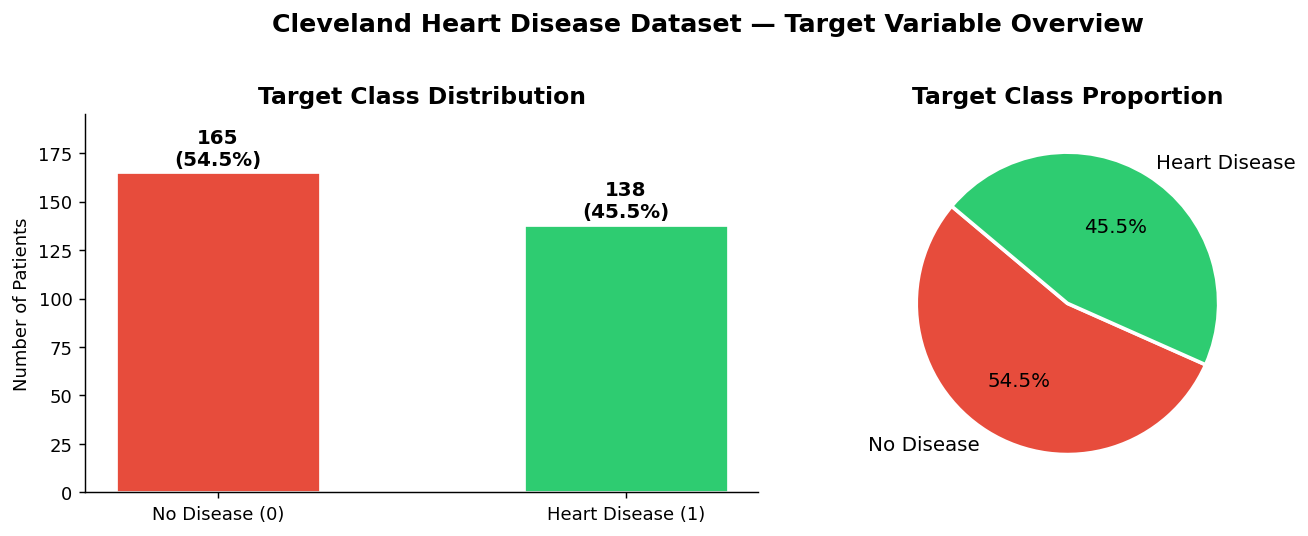

Plot saved to plots/target_distribution.png


In [14]:
import os
os.makedirs('plots', exist_ok=True)

target_counts = df['target'].value_counts()
target_pct    = df['target'].value_counts(normalize=True) * 100

print("TARGET CLASS DISTRIBUTION")
print("=" * 40)
print(f"No Heart Disease (0): {target_counts[0]} patients  ({target_pct[0]:.1f}%)")
print(f"Heart Disease    (1): {target_counts[1]} patients  ({target_pct[1]:.1f}%)")
print(f"\nClass Imbalance Ratio: {target_counts[1]/target_counts[0]:.2f}:1 (Disease:No Disease)")
print("\nObservation: Slight positive skew — 54.5% of patients have heart disease.")
print("The imbalance is mild and will be accounted for using stratified train/test split.")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
bars = axes[0].bar(['No Disease (0)', 'Heart Disease (1)'],
                   target_counts.values, color=PALETTE, edgecolor='white', linewidth=1.5, width=0.5)
for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Patients')
axes[0].set_ylim(0, max(target_counts.values) + 30)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Pie chart
axes[1].pie(target_counts.values, labels=['No Disease', 'Heart Disease'],
            colors=PALETTE, autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 11})
axes[1].set_title('Target Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Cleveland Heart Disease Dataset — Target Variable Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to plots/target_distribution.png")

## 2.7 Feature-wise Value Distributions

In [15]:
# Categorical feature value counts
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

print("VALUE COUNTS — CATEGORICAL FEATURES")
print("=" * 50)
for col in categorical_cols:
    print(f"\n{col.upper()}:")
    vc = df[col].value_counts().sort_index()
    for val, count in vc.items():
        print(f"  {val}: {count} patients ({count/len(df)*100:.1f}%)")

VALUE COUNTS — CATEGORICAL FEATURES

SEX:
  0: 96 patients (31.7%)
  1: 207 patients (68.3%)

CP:
  0: 143 patients (47.2%)
  1: 50 patients (16.5%)
  2: 87 patients (28.7%)
  3: 23 patients (7.6%)

FBS:
  0: 258 patients (85.1%)
  1: 45 patients (14.9%)

RESTECG:
  0: 147 patients (48.5%)
  1: 152 patients (50.2%)
  2: 4 patients (1.3%)

EXANG:
  0: 204 patients (67.3%)
  1: 99 patients (32.7%)

SLOPE:
  0: 21 patients (6.9%)
  1: 140 patients (46.2%)
  2: 142 patients (46.9%)

CA:
  0: 175 patients (57.8%)
  1: 65 patients (21.5%)
  2: 38 patients (12.5%)
  3: 20 patients (6.6%)
  4: 5 patients (1.7%)

THAL:
  0: 2 patients (0.7%)
  1: 18 patients (5.9%)
  2: 166 patients (54.8%)
  3: 117 patients (38.6%)


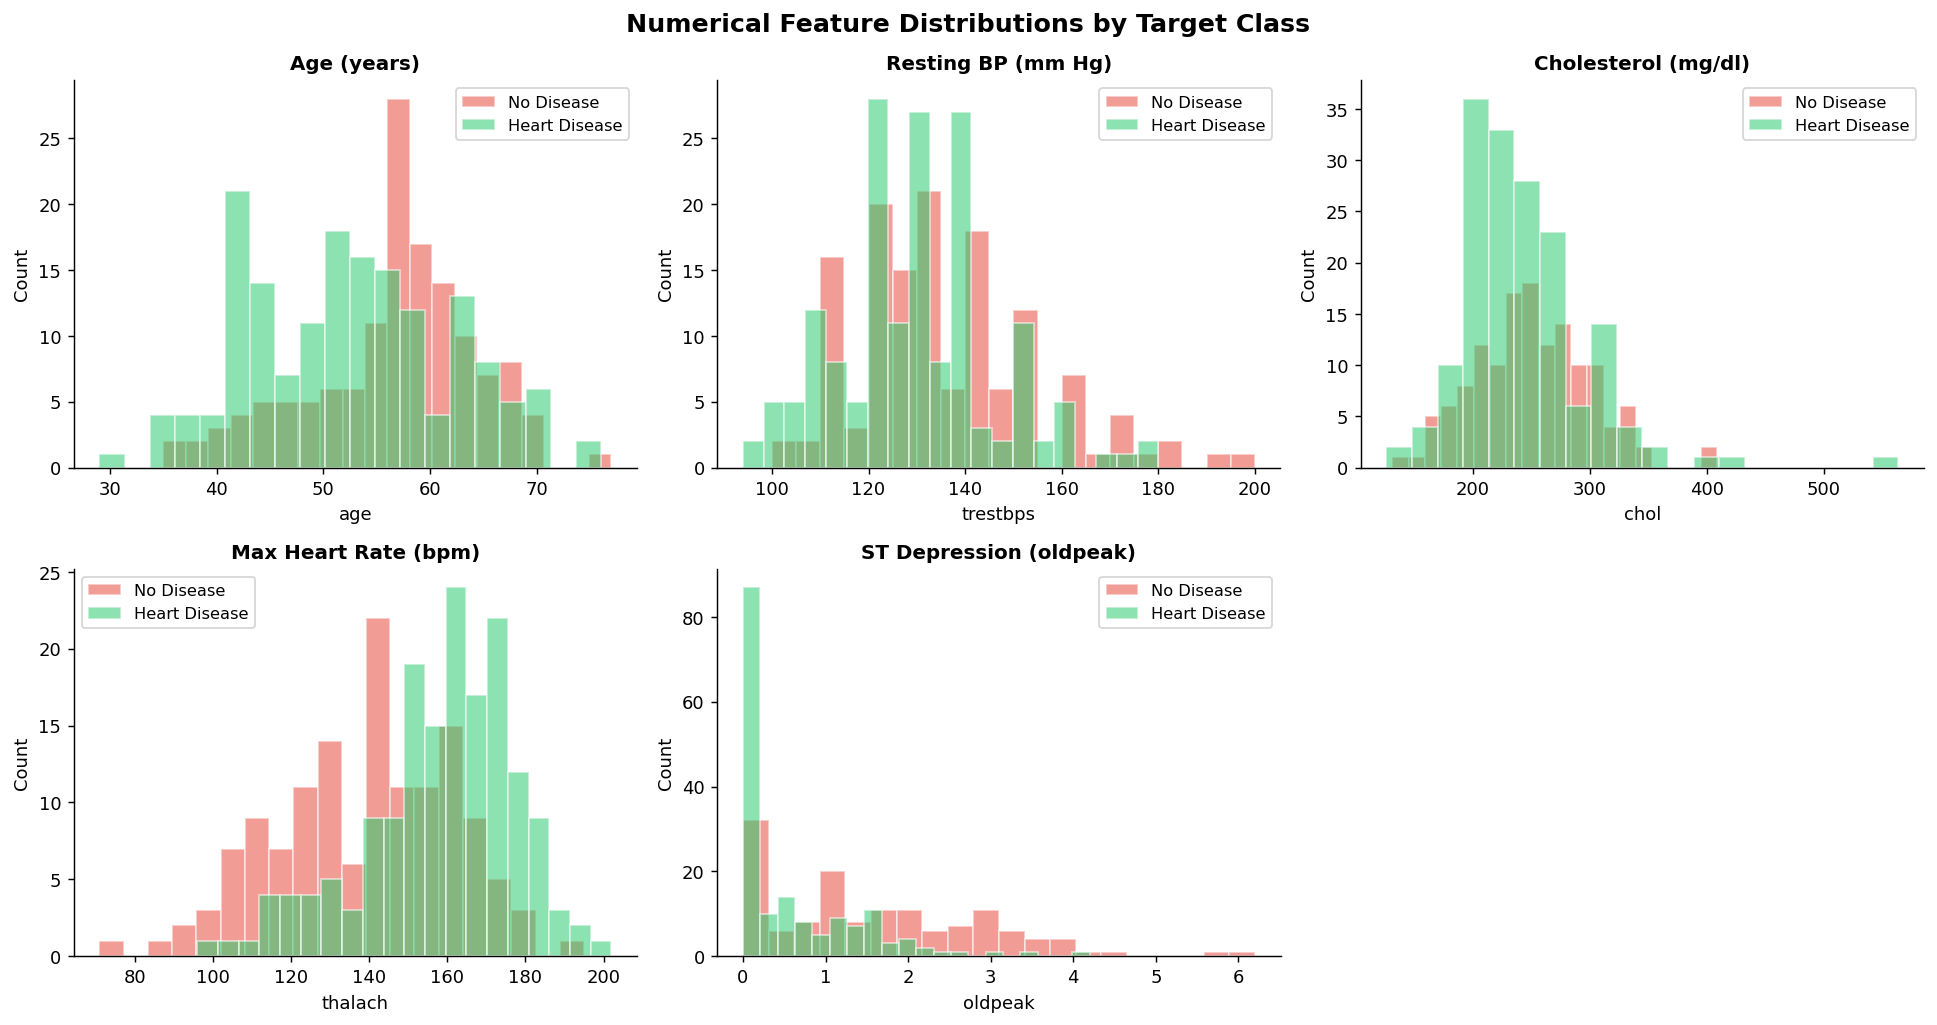

Saved to plots/feature_distributions.png


In [16]:
# Numerical feature range visualisation — KDE plots by target class
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

num_plot_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
titles = ['Age (years)', 'Resting BP (mm Hg)', 'Cholesterol (mg/dl)',
          'Max Heart Rate (bpm)', 'ST Depression (oldpeak)']

for i, (col, title) in enumerate(zip(num_plot_cols, titles)):
    for cls, color, label in zip([0, 1], PALETTE, ['No Disease', 'Heart Disease']):
        subset = df[df['target'] == cls][col]
        axes[i].hist(subset, bins=20, alpha=0.55, color=color, label=label, edgecolor='white')
    axes[i].set_title(title, fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=9)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

# Hide unused subplot
axes[5].axis('off')

plt.suptitle('Numerical Feature Distributions by Target Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to plots/feature_distributions.png")

## 2.8 Gender & Age Group Analysis

In [17]:
# Gender breakdown
gender_disease = df.groupby(['sex', 'target']).size().unstack(fill_value=0)
gender_disease.index = ['Female (0)', 'Male (1)']
gender_disease.columns = ['No Disease', 'Heart Disease']
print("DISEASE RATE BY SEX")
print("=" * 40)
print(gender_disease)
print()

# Disease rate by sex
male_df   = df[df['sex'] == 1]
female_df = df[df['sex'] == 0]
print(f"Male disease rate:   {male_df['target'].mean()*100:.1f}%  ({len(male_df)} total)")
print(f"Female disease rate: {female_df['target'].mean()*100:.1f}%  ({len(female_df)} total)")

# Age group analysis
bins   = [0, 40, 50, 60, 70, 100]
labels = ['<40', '40–49', '50–59', '60–69', '70+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

age_disease = df.groupby('age_group', observed=True)['target'].mean() * 100
print("\nDISEASE RATE BY AGE GROUP:")
print("=" * 40)
for group, rate in age_disease.items():
    print(f"  {group}: {rate:.1f}% disease rate")

# Drop temp column
df.drop(columns=['age_group'], inplace=True)

DISEASE RATE BY SEX
            No Disease  Heart Disease
Female (0)          24             72
Male (1)           114             93

Male disease rate:   44.9%  (207 total)
Female disease rate: 75.0%  (96 total)

DISEASE RATE BY AGE GROUP:
  <40: 68.4% disease rate
  40–49: 69.7% disease rate
  50–59: 49.6% disease rate
  60–69: 41.1% disease rate
  70+: 83.3% disease rate


## 2.9 Data Understanding Summary

| Finding | Detail |
|---|---|
| **Dataset Size** | 303 patients × 14 attributes |
| **Missing Values** | None — dataset is complete |
| **Duplicates** | None detected |
| **Class Balance** | 54.5% disease vs 45.5% no-disease (mild imbalance) |
| **Age Range** | 29 to 77 years; mean age ~54 years |
| **Gender Split** | ~68% male, ~32% female |
| **Key Observation 1** | Males have higher disease rates despite being more represented |
| **Key Observation 2** | `thalach` (max HR) shows clear separation between disease groups |
| **Key Observation 3** | `oldpeak` is right-skewed — most patients have low ST depression |
| **Key Observation 4** | `chol` has a wide range (126–564) — potential outliers to investigate in Stage 3 |

---
**Next Stage →** `03_data_preprocessing.ipynb`